## Import Libraries

In [93]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, OneHotEncoder, LabelEncoder
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    classification_report,
    ConfusionMatrixDisplay,
    confusion_matrix,
    roc_curve
)

import matplotlib.pyplot as plt
import plotly.express as px
import plotly.graph_objects as go

## Load dataset

In [94]:
df = pd.read_csv('./dataset/WA_Fn-UseC_-Telco-Customer-Churn.csv')

In [95]:
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [96]:
df.shape

(7043, 21)

In [97]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


## Data Preprocessing

In [98]:
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'],errors='coerce')
df["TotalCharges"] = df["TotalCharges"].fillna(0)
df.isnull().sum()

customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64

In [99]:
df['SeniorCitizen'] = df["SeniorCitizen"].map({0: "No", 1: "Yes"})

In [100]:
df = df.drop('customerID', axis=1)

df.head()

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,Female,No,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,Male,No,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.50,No
2,Male,No,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,Male,No,No,No,45,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,Female,No,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [101]:
# Encode output feature
churn_encode = LabelEncoder() # No: 0, Yes: 1
df['Churn'] = churn_encode.fit_transform(df['Churn'])

In [102]:
df.head(7)

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,Female,No,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,0
1,Male,No,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.50,0
2,Male,No,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,1
3,Male,No,No,No,45,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,0
4,Female,No,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,1
5,Female,No,No,No,8,Yes,Yes,Fiber optic,No,No,Yes,No,Yes,Yes,Month-to-month,Yes,Electronic check,99.65,820.50,1
6,Male,No,No,Yes,22,Yes,Yes,Fiber optic,No,Yes,No,No,Yes,No,Month-to-month,Yes,Credit card (automatic),89.10,1949.40,0


#### Separate Features and Target


In [103]:
X = df.drop('Churn', axis=1)
y = df['Churn']

#### Train test split

In [104]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

print("Training data:", X_train.shape)
print("Testing data :", X_test.shape)

Training data: (5634, 19)
Testing data : (1409, 19)


## Feature Engineering

In [105]:
categorical_cols = X_train.select_dtypes(include='object').columns
numwrical_cols = X_train.select_dtypes(include=['int64', 'float64']).columns

print(f'Numerical features: {numwrical_cols.to_list()}', '\n')
print(f'Categorical features: {categorical_cols.to_list()}')

Numerical features: ['tenure', 'MonthlyCharges', 'TotalCharges'] 

Categorical features: ['gender', 'SeniorCitizen', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod']


In [106]:
numerical_trf = Pipeline([
    ('num_impute', SimpleImputer(strategy='mean')), 
    ('scaler', StandardScaler())
])

In [107]:
catagorical_trf = Pipeline([
    ('cat_impute', SimpleImputer(strategy='most_frequent')), 
    ('ohe', OneHotEncoder(handle_unknown='ignore'))
])

In [108]:
preprocessor = ColumnTransformer([
    ('num', numerical_trf, numwrical_cols), 
    ('cat', catagorical_trf, categorical_cols)
])

In [109]:
X_train_processed = preprocessor.fit_transform(X_train)
X_test_processed = preprocessor.transform(X_test)

print("Training shape:", X_train_processed.shape)
print("Testing shape:",X_test_processed.shape)

Training shape: (5634, 46)
Testing shape: (1409, 46)


## Baseline Model Building

In [110]:
# Baseline Logistic Regression
lr_model = LogisticRegression(max_iter=1000)

In [111]:
lr_model.fit(X_train_processed, y_train)

LogisticRegression(max_iter=1000)

#### Predictions

In [112]:
y_pred = lr_model.predict(X_test_processed)
y_prob = lr_model.predict_proba(X_test_processed)[:, 1]

## Baseline Model Evaluation

In [113]:
lr_accuracy = accuracy_score(y_test,y_pred)
lr_precision = precision_score(y_test, y_pred) 
lr_recall = recall_score(y_test, y_pred)
lr_f1_score = f1_score(y_test, y_pred)
roc_auc = roc_auc_score(y_test, y_prob)

print('------Baseline Logistic Regression-------')
print('Accuracy: ',lr_accuracy)
print('Precision: ',lr_precision)
print('Recal: ', lr_recall)
print('F1 Score: ', lr_f1_score)
print("ROC-AUC  :", roc_auc)

------Baseline Logistic Regression-------
Accuracy:  0.8211497515968772
Precision:  0.6861538461538461
Recal:  0.5978552278820375
F1 Score:  0.6389684813753582
ROC-AUC  : 0.8622912935915618


In [114]:
print('------Baseline Logistic Regression-------')
print(classification_report(y_test, y_pred))

------Baseline Logistic Regression-------
              precision    recall  f1-score   support

           0       0.86      0.90      0.88      1036
           1       0.69      0.60      0.64       373

    accuracy                           0.82      1409
   macro avg       0.77      0.75      0.76      1409
weighted avg       0.82      0.82      0.82      1409



In [115]:
cm = confusion_matrix(y_test, y_pred)
print('------Baseline Logistic Regression-------')
cm

------Baseline Logistic Regression-------


array([[934, 102],
       [150, 223]])

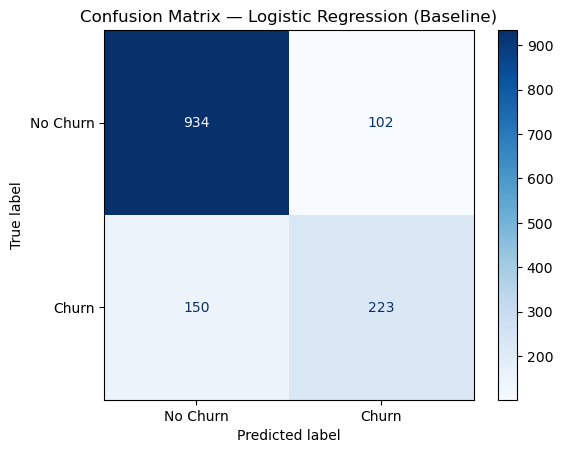

In [116]:
disp = ConfusionMatrixDisplay(
    confusion_matrix=cm, display_labels=["No Churn", "Churn"]
)
disp.plot(cmap=plt.cm.Blues)
plt.title('Confusion Matrix — Logistic Regression (Baseline)')
plt.show()

In [117]:
fpr, tpr, thresholds = roc_curve(y_test, y_prob)

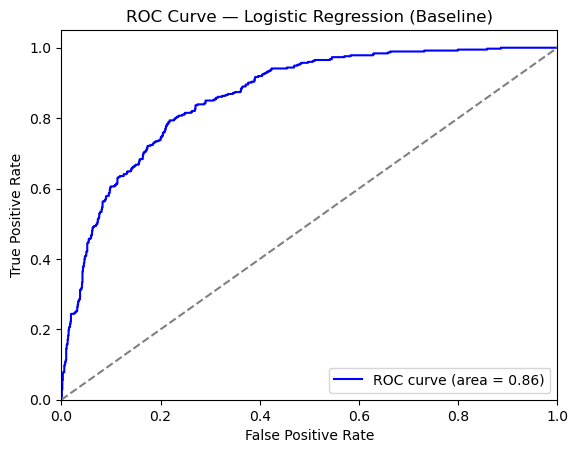

In [118]:
plt.figure()
plt.plot(
    fpr, tpr, color='blue', label=f'ROC curve (area = {roc_auc:.2f})'
)
plt.plot([0, 1], [0, 1], color='gray', linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve — Logistic Regression (Baseline)')
plt.legend(loc='lower right')
plt.show()

## Hyperparameter Tuning

In [119]:
param_grid = {
    'C': [0.001, 0.01, 0.1, 1, 10, 100],
    'penalty': ['l1', 'l2'],
    'solver': ['liblinear'],
    'class_weight': [None, 'balanced']
}

In [120]:
tuned_lr_model = LogisticRegression(max_iter=1000, random_state=42)

In [121]:
grid_search = GridSearchCV(
    estimator=tuned_lr_model,
    param_grid=param_grid,
    cv=5,
    scoring="recall",
    n_jobs=-1
)

In [122]:
grid_search.fit(
    X_train_processed,
    y_train
)

GridSearchCV(cv=5, estimator=LogisticRegression(max_iter=1000, random_state=42),
             n_jobs=-1,
             param_grid={'C': [0.001, 0.01, 0.1, 1, 10, 100],
                         'class_weight': [None, 'balanced'],
                         'penalty': ['l1', 'l2'], 'solver': ['liblinear']},
             scoring='recall')

In [123]:
print("Best parameters:")
print(grid_search.best_params_)

Best parameters:
{'C': 1, 'class_weight': 'balanced', 'penalty': 'l1', 'solver': 'liblinear'}


In [124]:
print("Best Cross-Validation recall:", round(grid_search.best_score_, 4))

Best Cross-Validation recall: 0.8008


In [125]:
best_lr_model = grid_search.best_estimator_

In [126]:
best_y_pred = best_lr_model.predict(X_test_processed)
best_y_prob = best_lr_model.predict_proba(X_test_processed)[:, 1]

In [127]:
best_lr_accuracy = accuracy_score(y_test,best_y_pred)
best_lr_precision = precision_score(y_test, best_y_pred) 
best_lr_recall = recall_score(y_test, best_y_pred)
best_lr_f1_score = f1_score(y_test, best_y_pred)
best_roc_auc = roc_auc_score(y_test, best_y_prob)

print('------Tuned Logistic Regression-------')

print('Accuracy: ',best_lr_accuracy)
print('Precision: ',best_lr_precision)
print('Recal: ', best_lr_recall)
print('F1 Score: ', best_lr_f1_score)
print("ROC-AUC  :", best_roc_auc)

------Tuned Logistic Regression-------
Accuracy:  0.751596877217885
Precision:  0.5192629815745393
Recal:  0.8310991957104558
F1 Score:  0.6391752577319587
ROC-AUC  : 0.8623094082209364


In [128]:
print('------Tuned Logistic Regression-------')
print(classification_report(y_test, best_y_pred))

------Tuned Logistic Regression-------
              precision    recall  f1-score   support

           0       0.92      0.72      0.81      1036
           1       0.52      0.83      0.64       373

    accuracy                           0.75      1409
   macro avg       0.72      0.78      0.72      1409
weighted avg       0.82      0.75      0.77      1409



In [129]:
best_lr_cm = confusion_matrix(y_test, best_y_pred)

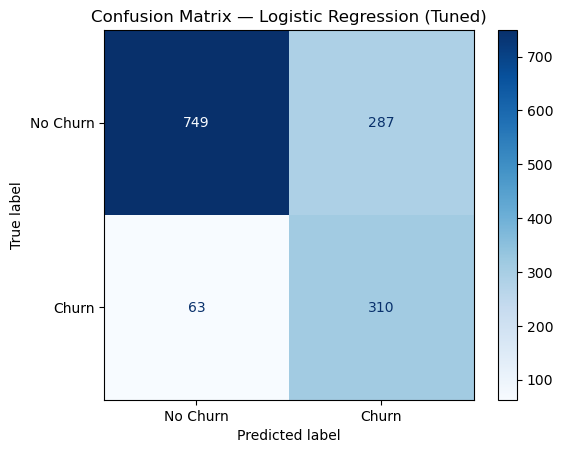

In [130]:
disp = ConfusionMatrixDisplay(
    confusion_matrix=best_lr_cm, display_labels=["No Churn", "Churn"]
)
disp.plot(cmap=plt.cm.Blues)
plt.title('Confusion Matrix — Logistic Regression (Tuned)')
plt.show()

Hyperparameter tuning substantially increased the model's ability to identify actual churners, improving recall from 59.79% to 83.11%, but this came with lower precision and accuracy and a substantial increase in false positives.

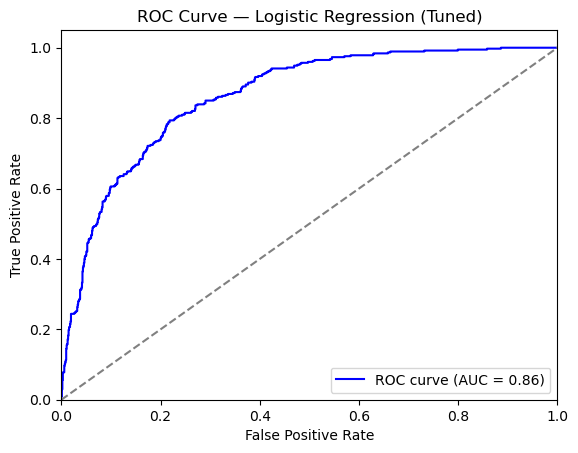

In [131]:
plt.figure()
plt.plot(
    fpr, tpr, color='blue', label=f'ROC curve (AUC = {best_roc_auc:.2f})'
)
plt.plot([0, 1], [0, 1], color='gray', linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve — Logistic Regression (Tuned)')
plt.legend(loc='lower right')
plt.show()

In [132]:
## Save best model

In [133]:
final_pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('model', best_lr_model)
])

In [134]:
final_pipeline.fit(X_train, y_train)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('num_impute',
                                                                   SimpleImputer()),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  Index(['tenure', 'MonthlyCharges', 'TotalCharges'], dtype='object')),
                                                 ('cat',
                                                  Pipeline(steps=[('cat_impute',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('ohe',
                                                                   OneHotEncoder(handle_unknown='ignore'))]),
                                                  Index(['g...r', 'Dependents', 'PhoneService',
       'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup',
       'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies',
       'Contract', 'PaperlessBilling', 'PaymentMethod'],
      dtype='object'))])),
                ('model',
                 LogisticRegression(C=1, class_weight='balanced', max_iter=1000,
                                    penalty='l1', random_state=42,
                                    solver='liblinear'))])

In [135]:
import joblib

joblib.dump(
    final_pipeline,
    './models/logistic_regression_churn.pkl'
)

print("Model saved successfully.")

Model saved successfully.
